In [1]:

import json
import pandas as pd


path = '/home/adrian.alvarez/Projects/diariodeleon-scraper/results/gpt4o_row_results/analisis_noticias.jsonl'
with open(path) as f:
    data = f.readlines()
# give a python dict
data = [json.loads(line) for line in data]


In [2]:
df = pd.DataFrame(data)
df.tail()

,url,title,subtitle,author,category,publication_date,updated_date,keywords,image,location,content,numero_protagonistas,numero_protagonistas_femeninos,numero_protagonistas_masculinos,numero_sujetos_secundarios,numero_sujetos_secundarios_femeninos,numero_sujetos_secundarios_masculinos,main_keywords,population_groups
8400,https://www.diariodeleon.es/ocio/destinos/2406...,"Astorga, ocio y deporte en las dos piscinas",Las instalaciones de verano mejoran con sombra...,A. Gaitero,Destinos,2024-06-25T20:49:31Z,2024-06-25T20:49:31Z,"[Astorga, Estadio La Eragudina, Medio ambiente...",https://imagenes.diariodeleon.es/files/article...,León,Las piscinas municipales de verano de Astorga ...,1,0,1,0,0,0,"piscinas, mantenimiento, ocio","vecinos, turistas"
8401,https://www.diariodeleon.es/opinion/240623/156...,Canto rodado: Sacri y los cuidados,N o sé qué habrá sido de Sacri. Hay personas q...,Ana Gaitero,Opinión,2024-06-23T01:30:00Z,2024-06-23T01:30:00Z,"[Discapacidad, ELA, Pensiones, Política, Villa...",https://imagenes.diariodeleon.es/files/article...,León,o sé qué habrá sido de Sacri. Hay personas que...,1,1,0,2,1,1,"cuidados, precariedad, política","personas mayores, personas migrantes"
8402,https://www.diariodeleon.es/leon/fiestas-san-j...,El Orgullo leonés se viste de fiesta y reivind...,"Moda, carrera de tacones, conciertos y la conm...",Ana Gaitero,Fiestas de San Juan y San Pedro,2024-06-19T19:07:19Z,2024-06-19T19:07:19Z,"[Día del Orgullo, León, LGTBI, Moda, Plaza de ...",https://imagenes.diariodeleon.es/files/article...,León,"San Juan, San Pedro y San Pelayo en el medio. ...",1,1,0,4,0,0,"reivindicación, celebración, derechos",comunidad LGTBIQ+
8403,https://www.diariodeleon.es/ocio/destinos/2406...,La casa de la luz,"Siete mil libros, fotografías y manuscritos, m...",Ana Gaitero,Destinos,2024-06-14T12:15:32Z,2024-06-14T12:15:32Z,"[La Bañeza, León, Libros, Poesía, Trabajo]",https://imagenes.diariodeleon.es/files/article...,León,la Casa de la Poesía de La Bañeza se accede po...,1,0,1,1,1,0,"poesía, legado, arte","escritores, poetas"
8404,https://www.diariodeleon.es/sociedad/mascotas/...,"Obi, la suave gatina de tres patas en busca de...",Obi es la gatita a la que se le pueden buscar ...,Ana Gaitero,Mascotas,2024-06-12T19:31:02Z,2024-06-12T19:31:02Z,"[Dietas, Vacunación]",https://imagenes.diariodeleon.es/files/article...,León,Obi es la gatita a la que se le pueden buscar ...,0,0,0,1,0,1,"adopción, rescate, felino",rescatistas de animales


In [3]:
from name_synonyms import SYNONYMS


def create_variant_to_canonical_mapping(variants_dict):
    """
    Creates a reverse mapping from normalized variants to canonical names.
    """
    variant_to_canonical = {}
    for canonical_name, variants in variants_dict.items():
        # Normalize the canonical name
        normalized_canonical_name = canonical_name
        # Map the normalized canonical name to itself
        variant_to_canonical[normalized_canonical_name] = canonical_name
        # Map each normalized variant to the canonical name
        for variant in variants:
            normalized_variant = variant
            variant_to_canonical[normalized_variant] = canonical_name
    return variant_to_canonical

roseta = create_variant_to_canonical_mapping(SYNONYMS)

In [4]:
df['author'] = df['author'].apply(lambda x: roseta.get(x, x))

In [5]:
df['gender_ratio_principales'] = df['numero_protagonistas_masculinos'] /(df['numero_protagonistas_masculinos'] + df['numero_protagonistas_femeninos'])

In [6]:
df['gender_ratio_secundario'] = df['numero_sujetos_secundarios_masculinos'] /(df['numero_sujetos_secundarios_masculinos'] + df['numero_sujetos_secundarios_femeninos'])

In [7]:

authors = [
    "Pacho Rodríguez",
    "Verónica Viñas",
    "María Carnero",
    "Pilar Infiesta",
    "Álvaro Caballero",
    "Luis Urdiales",
    "Cristina Fanjul",
    "Ángel Fraguas",
    "Maria Carro",
    "Manuel Félix",
    "Ángel Fidalgo",
    "Joaquín S.Torné",
    "Maite Rabanillo",
    "Maria Jesús Muñiz",
    "Carmen Tapia",
    "Ana Gil",
    "Miguel Angel Zamora",
    "Ana Gaitero",
]

In [8]:
#filter for authors
df = df[df['author'].isin(authors)]

In [9]:
group_df = df[['gender_ratio_secundario', 'author', 'gender_ratio_principales']].groupby('author').mean()

In [10]:
group_df['counts'] = df['author'].value_counts()

In [11]:
# Step 1: Multiply frequency values by 100 to get percentages
group_df['gender_ratio_principales'] = group_df['gender_ratio_principales'] * 100
group_df['gender_ratio_secundario'] = group_df['gender_ratio_secundario'] * 100

# Reset index to turn 'author' into a column
group_df = group_df.reset_index()


In [12]:
group_df

,author,gender_ratio_secundario,gender_ratio_principales,counts
0,Ana Gaitero,66.139057,54.137291,97
1,Ana Gil,55.142857,73.809524,14
2,Carmen Tapia,59.494568,57.685972,234
3,Cristina Fanjul,83.534392,74.274691,43
4,Luis Urdiales,88.200000,86.261261,92
5,Maite Rabanillo,92.433862,83.856516,69
6,Manuel Félix,84.503704,83.621554,139
7,Maria Carro,78.000000,75.138889,65
8,María Carnero,90.857843,81.237864,170
9,Miguel Angel Zamora,79.876244,66.666667,120


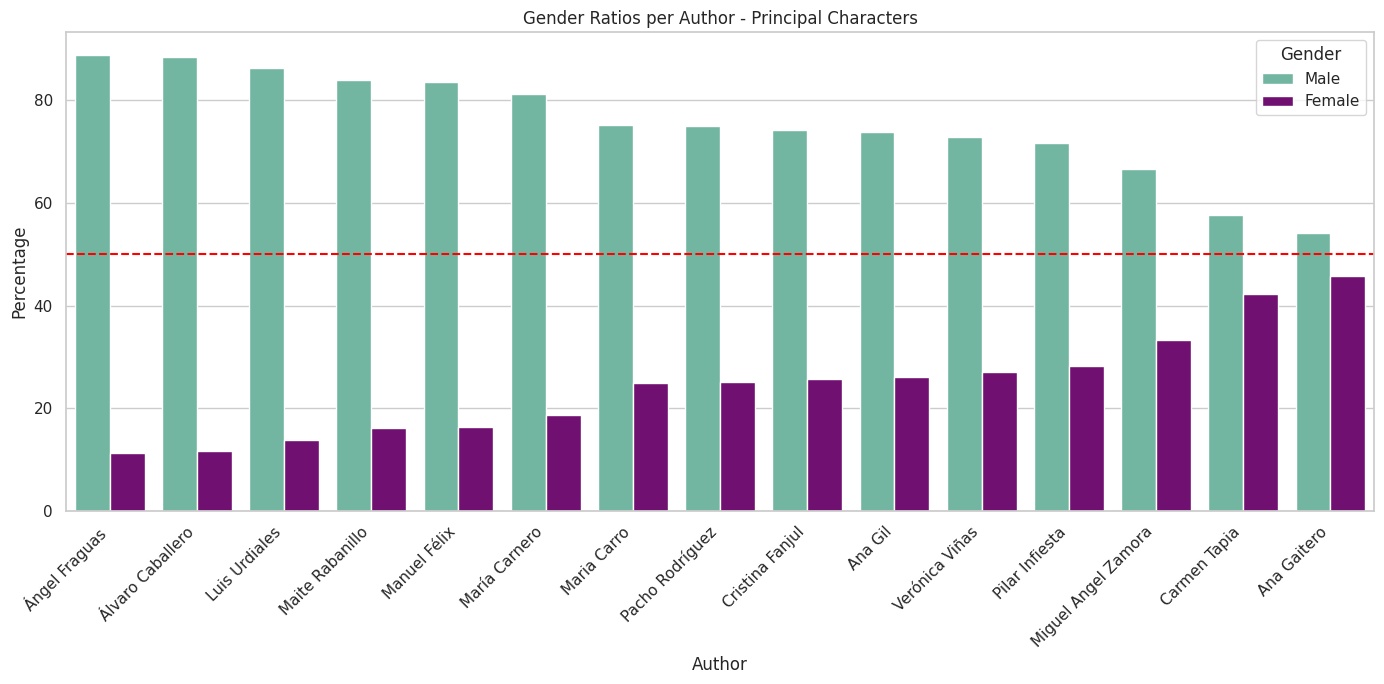

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Step 1.5: Order the DataFrame based on the male proportion
group_df = group_df.sort_values(by='gender_ratio_principales', ascending=False)

# Step 2: Prepare data for plotting
data = []
for idx, row in group_df.iterrows():
    author = row['author']
    male_percentage = row['gender_ratio_principales']
    female_percentage = 100 - male_percentage
    data.append({'Author': author, 'Gender': 'Male', 'Percentage': male_percentage})
    data.append({'Author': author, 'Gender': 'Female', 'Percentage': female_percentage})

plot_df = pd.DataFrame(data)

# Ensure the authors are in the correct order
plot_df['Author'] = pd.Categorical(plot_df['Author'], categories=group_df['author'], ordered=True)

# Step 3: Plot the data
plt.figure(figsize=(14, 7))
sns.set(style="whitegrid")

# Change the color of female bars to purple
palette = {'Male': sns.color_palette("Set2")[0], 'Female': 'purple'}

# Create the bar plot
sns.barplot(x='Author', y='Percentage', hue='Gender', data=plot_df, palette=palette)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add title and labels
plt.title('Gender Ratios per Author - Principal Characters')
plt.ylabel('Percentage')

# Draw a red dashed line at 50%
plt.axhline(50, color='red', linestyle='--')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

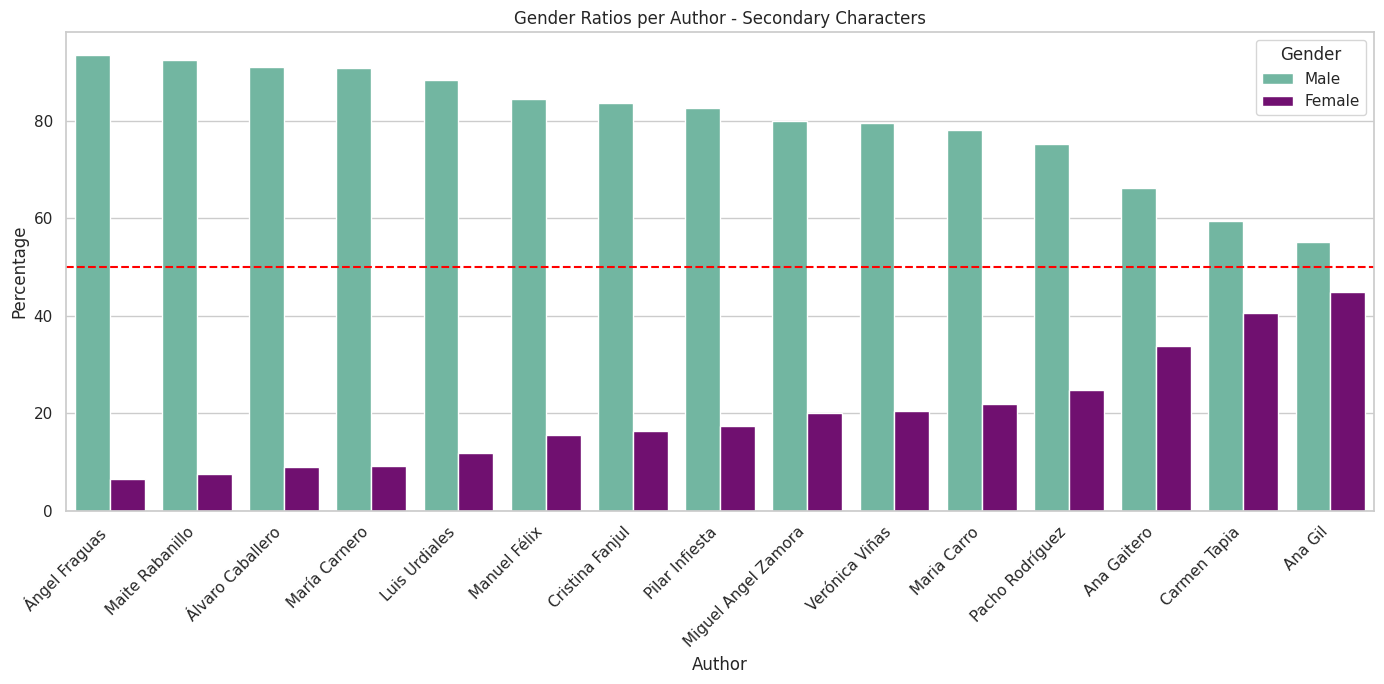

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Step 1.5: Order the DataFrame based on the male proportion
group_df = group_df.sort_values(by='gender_ratio_secundario', ascending=False)

# Step 2: Prepare data for plotting
data = []
for idx, row in group_df.iterrows():
    author = row['author']
    male_percentage = row['gender_ratio_secundario']
    female_percentage = 100 - male_percentage
    data.append({'Author': author, 'Gender': 'Male', 'Percentage': male_percentage})
    data.append({'Author': author, 'Gender': 'Female', 'Percentage': female_percentage})

plot_df = pd.DataFrame(data)

# Ensure the authors are in the correct order
plot_df['Author'] = pd.Categorical(plot_df['Author'], categories=group_df['author'], ordered=True)

# Step 3: Plot the data
plt.figure(figsize=(14, 7))
sns.set(style="whitegrid")

# Change the color of female bars to purple
palette = {'Male': sns.color_palette("Set2")[0], 'Female': 'purple'}

# Create the bar plot
sns.barplot(x='Author', y='Percentage', hue='Gender', data=plot_df, palette=palette)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add title and labels
plt.title('Gender Ratios per Author - Secondary Characters')
plt.ylabel('Percentage')

# Draw a red dashed line at 50%
plt.axhline(50, color='red', linestyle='--')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()